# Limpieza de Datos - Pregunta 1
**Pregunta de negocio:** ¿Cuál será el nivel de desempeño en matemáticas de un estudiante de Cundinamarca según su tipo de colegio?


In [2]:
#libreriass
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

#cargar datos y descomprimirlos porque estan en un .zip en el git
df = pd.read_csv('df_filtrado.csv.zip', compression= "zip")

## 1. Columnas relevantes

In [3]:
#columnas del dataframe
columnas = [
    'COLE_AREA_UBICACION',
    'COLE_BILINGUE',
    'COLE_GENERO',
    'COLE_JORNADA',
    'PUNT_MATEMATICAS'
]

df = df[columnas].copy()
print(f'Shape: {df.shape}')
df.head()

Shape: (470818, 5)


,COLE_AREA_UBICACION,COLE_BILINGUE,COLE_GENERO,COLE_JORNADA,PUNT_MATEMATICAS
0,URBANO,N,MIXTO,UNICA,26.0
1,URBANO,N,MIXTO,SABATINA,60.0
2,URBANO,NaN,MIXTO,COMPLETA,61.0
3,URBANO,N,MIXTO,COMPLETA,54.0
4,RURAL,N,MIXTO,SABATINA,45.0


## 2. Calidad de datos por columna

In [4]:
# Valores que se consideran "sin dato"
valores_nulos = {'na', 'nan', 'n/a', 'null', 'none', '-', ' ', ''}

print('Valores nulos y vacíos por columna (antes de limpiar)')
for col in columnas:
    problemas = df[col].apply(
        lambda x: pd.isna(x) or str(x).strip().lower() in valores_nulos
    ).sum()
    pct = problemas / len(df) * 100
    print(f'{col}: {problemas} problemas ({pct:.1f}%) — {len(df) - problemas} datos útiles')

# Eliminar filas con nulos en cualquier columna relevante
antes = len(df)
mask = df[columnas].apply(
    lambda col: col.apply(
        lambda x: pd.isna(x) or str(x).strip().lower() in valores_nulos
    )
).any(axis=1)
df = df[~mask].reset_index(drop=True)

print(f'\nRegistros eliminados : {antes - len(df):,}')
print(f'Registros restantes  : {len(df):,}')

Valores nulos y vacíos por columna (antes de limpiar)
COLE_AREA_UBICACION: 198 problemas (0.0%) — 470620 datos útiles
COLE_BILINGUE: 77355 problemas (16.4%) — 393463 datos útiles
COLE_GENERO: 0 problemas (0.0%) — 470818 datos útiles
COLE_JORNADA: 0 problemas (0.0%) — 470818 datos útiles
PUNT_MATEMATICAS: 0 problemas (0.0%) — 470818 datos útiles

Registros eliminados : 77,553
Registros restantes  : 393,265


In [5]:
print('Valores únicos por columna categórica\n')
for col in ['COLE_AREA_UBICACION', 'COLE_BILINGUE', 'COLE_GENERO', 'COLE_JORNADA', "PUNT_MATEMATICAS"]:
    print(f'--- {col} ---')
    print(df[col].value_counts(dropna=False))
    print()


Valores únicos por columna categórica

--- COLE_AREA_UBICACION ---
COLE_AREA_UBICACION
URBANO    320952
RURAL      72313
Name: count, dtype: int64

--- COLE_BILINGUE ---
COLE_BILINGUE
N    387178
S      6087
Name: count, dtype: int64

--- COLE_GENERO ---
COLE_GENERO
MIXTO        387378
FEMENINO       4297
MASCULINO      1590
Name: count, dtype: int64

--- COLE_JORNADA ---
COLE_JORNADA
MAÑANA      177781
COMPLETA     99506
UNICA        35440
TARDE        30687
NOCHE        25569
SABATINA     24282
Name: count, dtype: int64

--- PUNT_MATEMATICAS ---
PUNT_MATEMATICAS
49.00     17578
52.00     16925
55.00     14524
46.00     13488
45.00     12851
          ...  
8.00          1
8.57          1
103.94        1
22.65         1
93.80         1
Name: count, Length: 280, dtype: int64



## 3. Letras a numeros

In [6]:
#bilingue o no
df['COLE_BILINGUE_NUM'] = df['COLE_BILINGUE'].map({'S': 1, 'N': 0})

#generos
df['COLE_GENERO_NUM'] = df['COLE_GENERO'].map({'MIXTO': 1, 'FEMENINO': 2, 'MASCULINO': 3})

#jornadas 
df['COLE_JORNADA_NUM'] = df['COLE_JORNADA'].map({
    'MAÑANA': 1,
    'COMPLETA': 2,
    'UNICA': 3,
    'TARDE': 4,
    'NOCHE': 5,
    'SABATINA': 6
})

#ubicacion
df['COLE_AREA_UBICACION_NUM'] = df['COLE_AREA_UBICACION'].map({'URBANO': 0, 'RURAL': 1})

#dataframe sin nulos y con numeros
df_limpio = df[[
    'COLE_AREA_UBICACION_NUM',
    'COLE_BILINGUE_NUM',
    'COLE_GENERO_NUM',
    'COLE_JORNADA_NUM',
    "PUNT_MATEMATICAS",
]].dropna().reset_index(drop=True)

print(f'Shape final: {df_limpio.shape}')
print(f'Nulos restantes: {df_limpio.isna().sum().sum()}')
df_limpio.head()

Shape final: (393265, 5)
Nulos restantes: 0


,COLE_AREA_UBICACION_NUM,COLE_BILINGUE_NUM,COLE_GENERO_NUM,COLE_JORNADA_NUM,PUNT_MATEMATICAS
0,0,0,1,3,26.0
1,0,0,1,6,60.0
2,0,0,1,2,54.0
3,1,0,1,6,45.0
4,0,0,1,3,64.0


# Exploración de Datos - Pregunta 1
**Pregunta de negocio:** ¿Cuál será el nivel de desempeño en matemáticas de un estudiante de Cundinamarca según su tipo de colegio?


## 3. Distribución de PUNT_MATEMATICAS y definición de categorías

In [7]:
#estadisticas base 
print('Estadísticas de PUNT_MATEMATICAS')
print(df['PUNT_MATEMATICAS'].describe())
print(f'\nPercentil 33: {df["PUNT_MATEMATICAS"].quantile(0.33):.1f}')
print(f'Percentil 66: {df["PUNT_MATEMATICAS"].quantile(0.66):.1f}')

Estadísticas de PUNT_MATEMATICAS
count    393265.000000
mean         50.553813
std          11.238088
min           0.000000
25%          43.000000
50%          50.000000
75%          58.000000
max         127.000000
Name: PUNT_MATEMATICAS, dtype: float64

Percentil 33: 45.4
Percentil 66: 55.0


In [8]:
#nivel de matematicas basado en los percentiles
p33 = df['PUNT_MATEMATICAS'].quantile(0.33)
p66 = df['PUNT_MATEMATICAS'].quantile(0.66)

print(f'Umbrales:')
print(f'  Bajo  : PUNT_MATEMATICAS < {p33:.1f}')
print(f'  Medio : {p33:.1f} <= PUNT_MATEMATICAS < {p66:.1f}')
print(f'  Alto  : PUNT_MATEMATICAS >= {p66:.1f}')

def categorizar(puntaje):
    if pd.isna(puntaje):
        return np.nan
    elif puntaje < p33:
        return 'Bajo'
    elif puntaje < p66:
        return 'Medio'
    else:
        return 'Alto'

df['NIVEL_MATEMATICAS'] = df['PUNT_MATEMATICAS'].apply(categorizar)
print('\n=== Distribución de categorías ===')
print(df['NIVEL_MATEMATICAS'].value_counts())

Umbrales:
  Bajo  : PUNT_MATEMATICAS < 45.4
  Medio : 45.4 <= PUNT_MATEMATICAS < 55.0
  Alto  : PUNT_MATEMATICAS >= 55.0

=== Distribución de categorías ===
NIVEL_MATEMATICAS
Alto     140601
Bajo     128550
Medio    124114
Name: count, dtype: int64


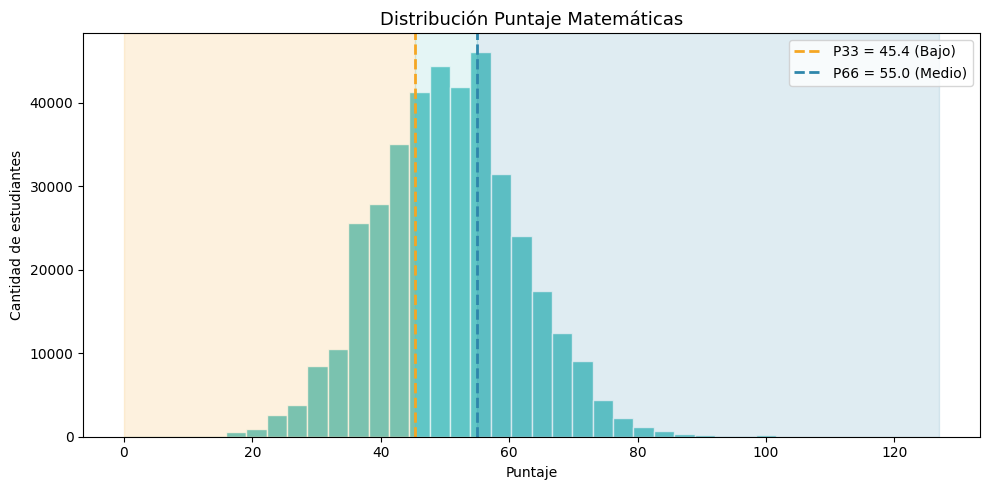

In [9]:
plt.figure(figsize=(10, 5), facecolor='white')
plt.grid(False)

#datos e histograma
plt.hist(df['PUNT_MATEMATICAS'].dropna(), bins=40, color='#4ABFBF', edgecolor='white', alpha=0.85)

plt.axvline(p33, color='#F5A623', linestyle='--', linewidth=2, label=f'P33 = {p33:.1f} (Bajo)')
plt.axvline(p66, color='#2E86AB', linestyle='--', linewidth=2, label=f'P66 = {p66:.1f} (Medio)')

plt.axvspan(df['PUNT_MATEMATICAS'].min(), p33, alpha=0.15, color='#F5A623')
plt.axvspan(p33, p66, alpha=0.15, color='#4ABFBF')
plt.axvspan(p66, df['PUNT_MATEMATICAS'].max(), alpha=0.15, color='#2E86AB')

#etiquetas y titulos
plt.title('Distribución Puntaje Matemáticas', fontsize=13)
plt.xlabel('Puntaje')
plt.ylabel('Cantidad de estudiantes')
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
#colores de la presentacion
C = {'Bajo': '#F5A623', 'Medio': '#4ABFBF', 'Alto': '#2E86AB'}
ORDEN = ['Bajo', 'Medio', 'Alto']
sns.set_theme(style='whitegrid', font_scale=1.05)

#percentiles para definir los niveles
p33 = df['PUNT_MATEMATICAS'].quantile(0.33)
p66 = df['PUNT_MATEMATICAS'].quantile(0.66)

#imprimir bonito
print(f'Registros: {len(df_limpio):,}   |  p33={p33:.1f}  p66={p66:.1f}')
print(df['NIVEL_MATEMATICAS'].value_counts().reindex(ORDEN))

Registros: 393,265   |  p33=45.4  p66=55.0
NIVEL_MATEMATICAS
Bajo     128550
Medio    124114
Alto     140601
Name: count, dtype: int64


## Histogramas

── Área de Ubicación ──
  Urbano           320,952  (81.6%)
  Rural             72,313  (18.4%)

── Bilingüe ──
  No               387,178  (98.5%)
  Sí                 6,087  (1.5%)

── Género del Colegio ──
  Mixto            387,378  (98.5%)
  Femenino           4,297  (1.1%)
  Masculino          1,590  (0.4%)

── Jornada ──
  Mañana           177,781  (45.2%)
  Completa          99,506  (25.3%)
  Única             35,440  (9.0%)
  Tarde             30,687  (7.8%)
  Noche             25,569  (6.5%)
  Sabatina          24,282  (6.2%)



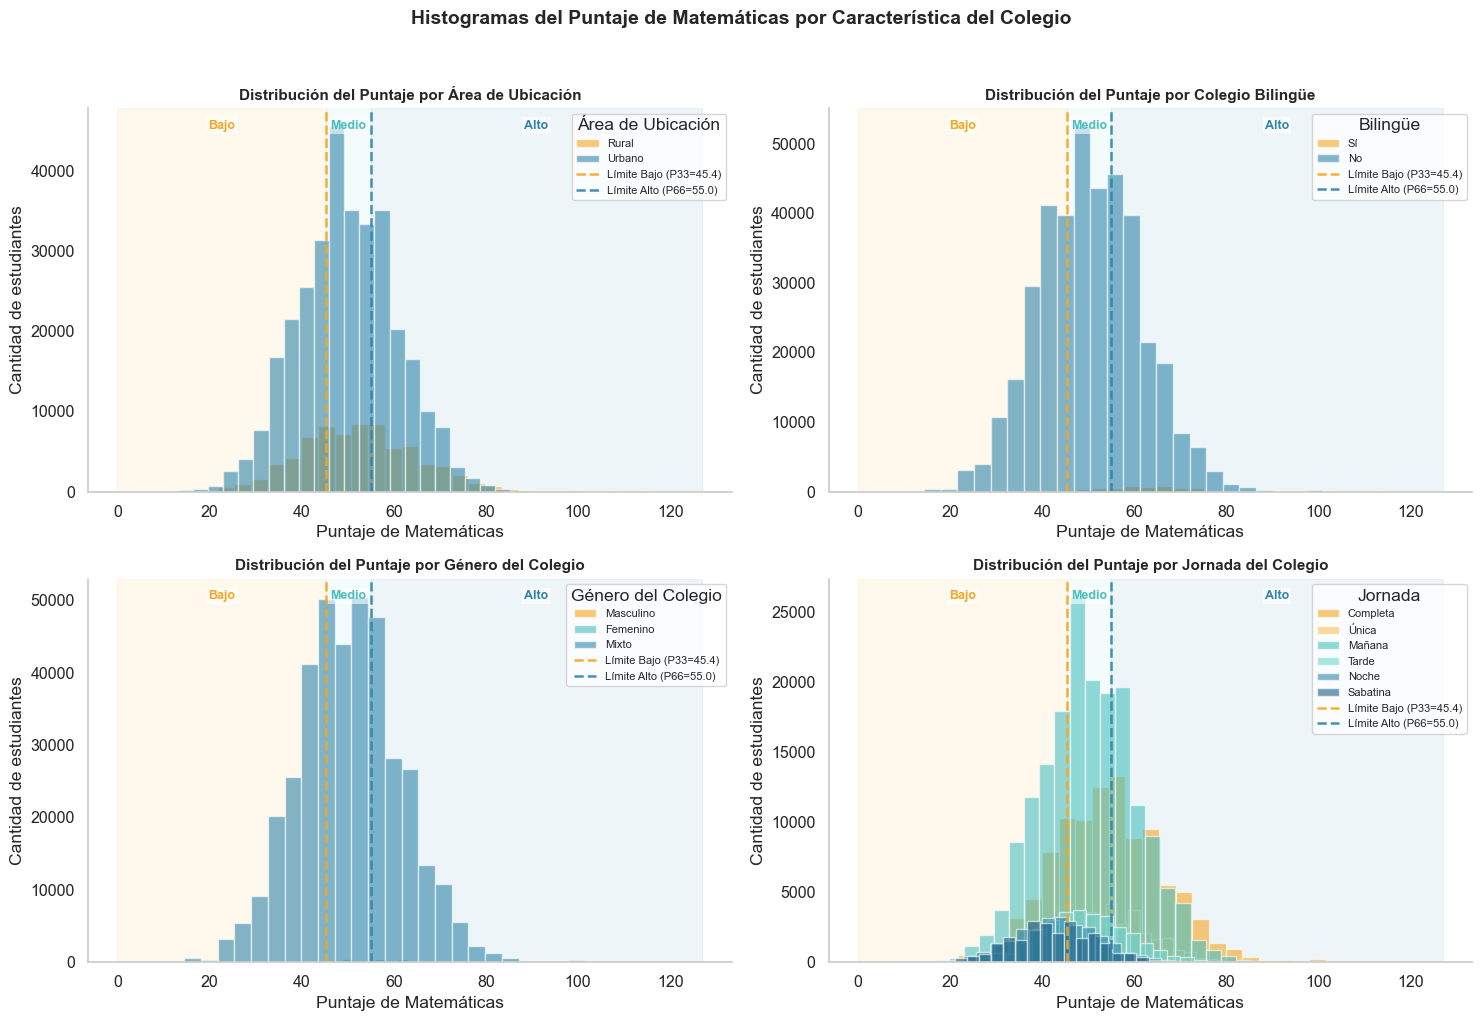

In [11]:
#colores combinados con los de la pp
C = {'Bajo': '#F5A623', 'Medio': '#4ABFBF', 'Alto': '#2E86AB'}

PALETAS = {
    'COLE_AREA_UBICACION': ['#F5A623', '#2E86AB'],
    'COLE_BILINGUE':       ['#F5A623', '#2E86AB'],
    'COLE_GENERO':         ['#F5A623', '#4ABFBF', '#2E86AB'],
    'COLE_JORNADA':        ['#F5A623', '#F8C15C', '#4ABFBF',
                            '#6FD4D4', '#2E86AB', '#1B5E84'],
}

#titulos y subtitulos bonitos
TITULO_PRINCIPAL = "Histogramas del Puntaje de Matemáticas por Característica del Colegio"

TITULOS_SUBPLOTS = {
    'COLE_AREA_UBICACION': "Distribución del Puntaje por Área de Ubicación",
    'COLE_BILINGUE':       "Distribución del Puntaje por Colegio Bilingüe",
    'COLE_GENERO':         "Distribución del Puntaje por Género del Colegio",
    'COLE_JORNADA':        "Distribución del Puntaje por Jornada del Colegio",
}

XLABELS = {
    'COLE_AREA_UBICACION': "Puntaje de Matemáticas",
    'COLE_BILINGUE':       "Puntaje de Matemáticas",
    'COLE_GENERO':         "Puntaje de Matemáticas",
    'COLE_JORNADA':        "Puntaje de Matemáticas",
}

#nombres 
df_plot = df.copy()
df_plot['COLE_AREA_UBICACION'] = df_plot['COLE_AREA_UBICACION'].replace({'URBANO': 'Urbano', 'RURAL': 'Rural'})
df_plot['COLE_BILINGUE']       = df_plot['COLE_BILINGUE'].replace({'N': 'No', 'S': 'Sí'})
df_plot['COLE_GENERO']         = df_plot['COLE_GENERO'].replace({'MIXTO': 'Mixto', 'FEMENINO': 'Femenino', 'MASCULINO': 'Masculino'})
df_plot['COLE_JORNADA']        = df_plot['COLE_JORNADA'].replace({'SABATINA': 'Sabatina', 'NOCHE': 'Noche',
                                                                    'TARDE': 'Tarde', 'MAÑANA': 'Mañana',
                                                                    'COMPLETA': 'Completa', 'UNICA': 'Única'})

#umbrales
p33   = df_plot['PUNT_MATEMATICAS'].quantile(0.33)
p66   = df_plot['PUNT_MATEMATICAS'].quantile(0.66)
ymin  = df_plot['PUNT_MATEMATICAS'].min()
ymax  = df_plot['PUNT_MATEMATICAS'].max()

# frecuencias
cats = [
    ('COLE_AREA_UBICACION', 'Área de Ubicación'),
    ('COLE_BILINGUE',       'Bilingüe'),
    ('COLE_GENERO',         'Género del Colegio'),
    ('COLE_JORNADA',        'Jornada'),
]
for var, label in cats:
    vc  = df_plot[var].value_counts()
    pct = (vc / vc.sum() * 100).round(1)
    print(f'── {label} ──')
    for k in vc.index:
        print(f'  {str(k):<15} {vc[k]:>8,}  ({pct[k]:.1f}%)')
    print()

fig, axes = plt.subplots(2, 2, figsize=(15, 10), facecolor='white')
axes = axes.flatten()

for i, (var, label) in enumerate(cats):
    ax = axes[i]
    ax.set_facecolor('white')

    #ordenas categorias
    orden_cat = df_plot.groupby(var)['PUNT_MATEMATICAS'].median().sort_values(ascending=False).index.tolist()
    colores   = PALETAS[var]

    for cat_val, color in zip(orden_cat, colores):
        datos = df_plot[df_plot[var] == cat_val]['PUNT_MATEMATICAS'].dropna()
        ax.hist(datos, bins=35, alpha=0.6, label=str(cat_val),
                color=color, edgecolor='white')

    #niveles y percentiles
    ax.axvspan(ymin, p33, alpha=0.08, color=C['Bajo'],  zorder=0)
    ax.axvspan(p33,  p66, alpha=0.06, color=C['Medio'], zorder=0)
    ax.axvspan(p66,  ymax, alpha=0.08, color=C['Alto'], zorder=0)

    #umbral
    ax.axvline(p33, color=C['Bajo'], ls='--', lw=1.8, alpha=0.9,
               label=f'Límite Bajo (P33={p33:.1f})')
    ax.axvline(p66, color=C['Alto'], ls='--', lw=1.8, alpha=0.9,
               label=f'Límite Alto (P66={p66:.1f})')

    #etiquetas necesarias 
    ymax_ax = ax.get_ylim()[1] if ax.get_ylim()[1] != 1.0 else 1
    for txt, xpos, color in [
        ('Bajo',  (ymin + p33) / 2, C['Bajo']),
        ('Medio', (p33  + p66) / 2, C['Medio']),
        ('Alto',  (p66  + ymax) / 2, C['Alto']),
    ]:
        ax.text(xpos, ax.get_ylim()[1] * 0.97 if ax.get_ylim()[1] != 1.0 else 0.97,
                txt, color=color, fontsize=9, fontweight='bold',
                ha='center', va='top',
                bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1.5))

    #titulos
    ax.set_title(TITULOS_SUBPLOTS[var], fontweight='bold', fontsize=11)
    ax.set_xlabel(XLABELS[var]); ax.set_ylabel('Cantidad de estudiantes')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(False)
    ax.legend(title=label, fontsize=8)

plt.suptitle(TITULO_PRINCIPAL, fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Diagrama de caja y bigotes

C:\Users\danis\AppData\Local\Temp\ipykernel_16052\278720716.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


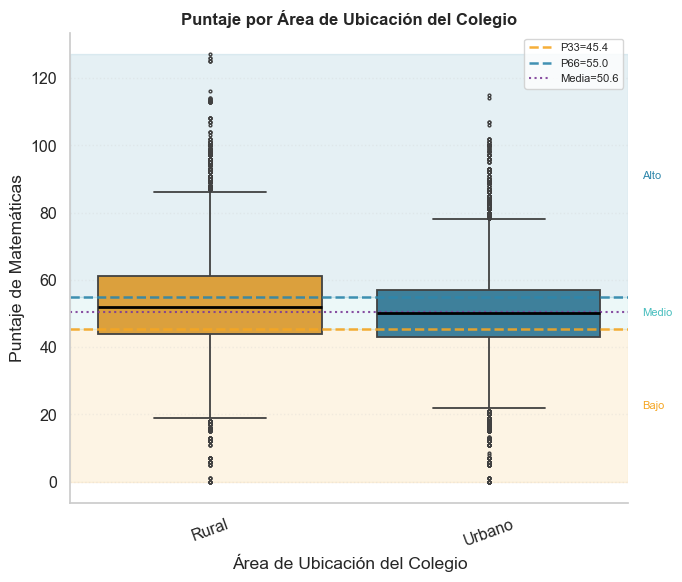

C:\Users\danis\AppData\Local\Temp\ipykernel_16052\278720716.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


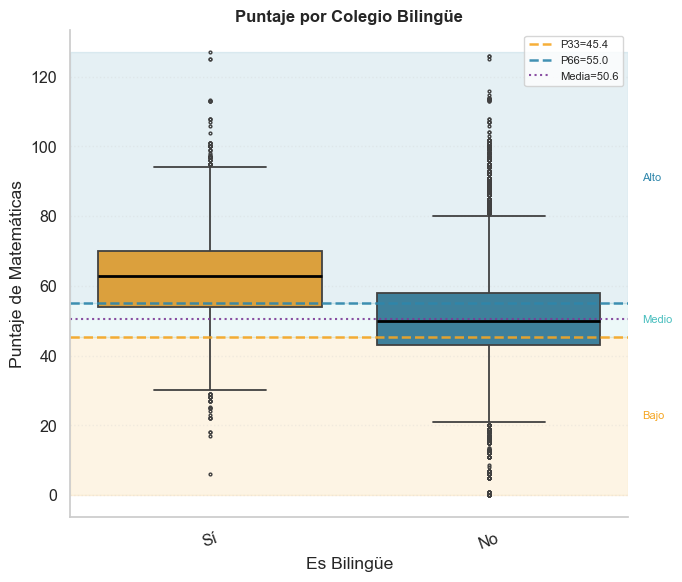

C:\Users\danis\AppData\Local\Temp\ipykernel_16052\278720716.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


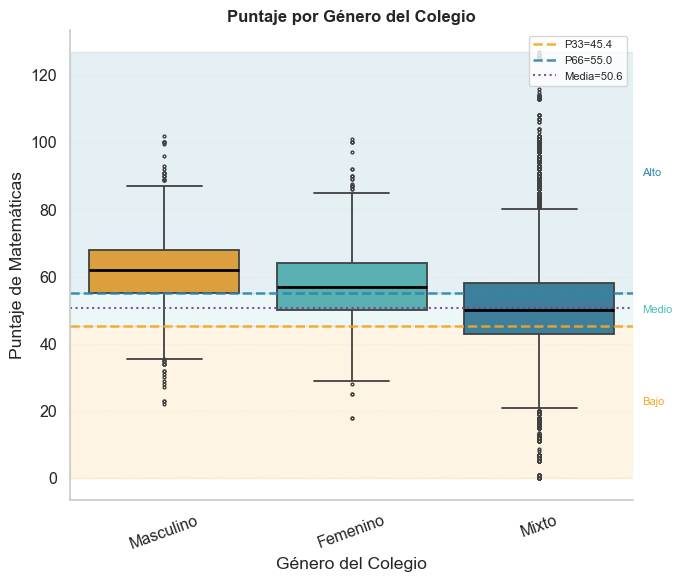

C:\Users\danis\AppData\Local\Temp\ipykernel_16052\278720716.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


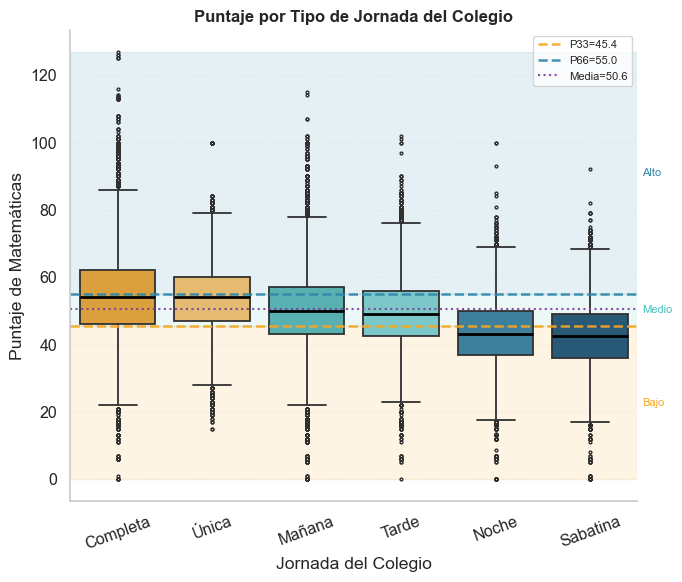

In [12]:
#colores de la pp
C = {'Bajo': '#F5A623', 'Medio': '#4ABFBF', 'Alto': '#2E86AB'}

PALETAS = {
    'COLE_AREA_UBICACION': ['#F5A623', '#2E86AB'],
    'COLE_BILINGUE':       ['#F5A623', '#2E86AB'],
    'COLE_GENERO':         ['#F5A623', '#4ABFBF', '#2E86AB'],
    'COLE_JORNADA':        ['#F5A623', '#F8C15C', '#4ABFBF',
                            '#6FD4D4', '#2E86AB', '#1B5E84'],
}

#titulos
TITULOS_SUBPLOTS = {
    'COLE_AREA_UBICACION': "Puntaje por Área de Ubicación del Colegio",
    'COLE_BILINGUE':       "Puntaje por Colegio Bilingüe",
    'COLE_GENERO':         "Puntaje por Género del Colegio",
    'COLE_JORNADA':        "Puntaje por Tipo de Jornada del Colegio"
}

XLABELS = {
    'COLE_AREA_UBICACION': "Área de Ubicación del Colegio",
    'COLE_BILINGUE':       "Es Bilingüe",
    'COLE_GENERO':         "Género del Colegio",
    'COLE_JORNADA':        "Jornada del Colegio"
}

YLABEL = "Puntaje de Matemáticas"

#limpieza nombres
df_plot = df.copy()
df_plot['COLE_AREA_UBICACION'] = df_plot['COLE_AREA_UBICACION'].replace({'URBANO': 'Urbano', 'RURAL': 'Rural'})
df_plot['COLE_BILINGUE']       = df_plot['COLE_BILINGUE'].replace({'N': 'No', 'S': 'Sí'})
df_plot['COLE_GENERO']         = df_plot['COLE_GENERO'].replace({'MIXTO': 'Mixto', 'FEMENINO': 'Femenino', 'MASCULINO': 'Masculino'})
df_plot['COLE_JORNADA']        = df_plot['COLE_JORNADA'].replace({'SABATINA': 'Sabatina', 'NOCHE': 'Noche',
                                                                'TARDE': 'Tarde', 'MAÑANA': 'Mañana',
                                                                'COMPLETA': 'Completa', 'UNICA': 'Única'})

#niveles
p33   = df_plot['PUNT_MATEMATICAS'].quantile(0.33)
p66   = df_plot['PUNT_MATEMATICAS'].quantile(0.66)
media = df_plot['PUNT_MATEMATICAS'].mean()
ymin  = df_plot['PUNT_MATEMATICAS'].min()
ymax  = df_plot['PUNT_MATEMATICAS'].max()

for i, (var, label) in enumerate(cats):

    # 🔹 NUEVA FIGURA
    fig, ax = plt.subplots(figsize=(7, 6), facecolor='white')
    ax.set_facecolor('white')

    orden_cat = df_plot.groupby(var)['PUNT_MATEMATICAS'].median().sort_values(ascending=False).index.tolist()
    palette   = PALETAS.get(var, ['#4ABFBF'])

    # boxplot
    sns.boxplot(
        data=df_plot, x=var, y='PUNT_MATEMATICAS',
        order=orden_cat, palette=palette,
        fliersize=2, linewidth=1.3,
        boxprops={'linewidth': 1.3},
        medianprops={'color': '#000000', 'linewidth': 2},
        whiskerprops={'linewidth': 1.3},
        ax=ax
    )

    # bandas
    ax.axhspan(ymin, p33, alpha=0.12, color=C['Bajo'],  zorder=0)
    ax.axhspan(p33,  p66, alpha=0.10, color=C['Medio'], zorder=0)
    ax.axhspan(p66,  ymax, alpha=0.12, color=C['Alto'], zorder=0)

    # líneas
    ax.axhline(p33,   color=C['Bajo'],  ls='--', lw=1.8, alpha=0.9, label=f'P33={p33:.1f}')
    ax.axhline(p66,   color=C['Alto'],  ls='--', lw=1.8, alpha=0.9, label=f'P66={p66:.1f}')
    ax.axhline(media, color='#7D3C98',  ls=':',  lw=1.5, alpha=0.9, label=f'Media={media:.1f}')

    # etiquetas zonas
    n_cats = len(orden_cat)
    ax.text(n_cats - 0.45, (ymin + p33) / 2, 'Bajo',  color=C['Bajo'],  fontsize=8, va='center')
    ax.text(n_cats - 0.45, (p33 + p66)  / 2, 'Medio', color=C['Medio'], fontsize=8, va='center')
    ax.text(n_cats - 0.45, (p66 + ymax) / 2, 'Alto',  color=C['Alto'],  fontsize=8, va='center')

    # estilo
    ax.set_title(TITULOS_SUBPLOTS[var], fontweight='bold', fontsize=12)
    ax.set_xlabel(XLABELS[var])
    ax.set_ylabel(YLABEL)

    ax.tick_params(axis='x', rotation=20)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle=':', alpha=0.25)

    ax.legend(fontsize=8, loc='upper right')

    plt.tight_layout()
    
    plt.show()

## Diagramas de violín

C:\Users\danis\AppData\Local\Temp\ipykernel_16052\3747627729.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


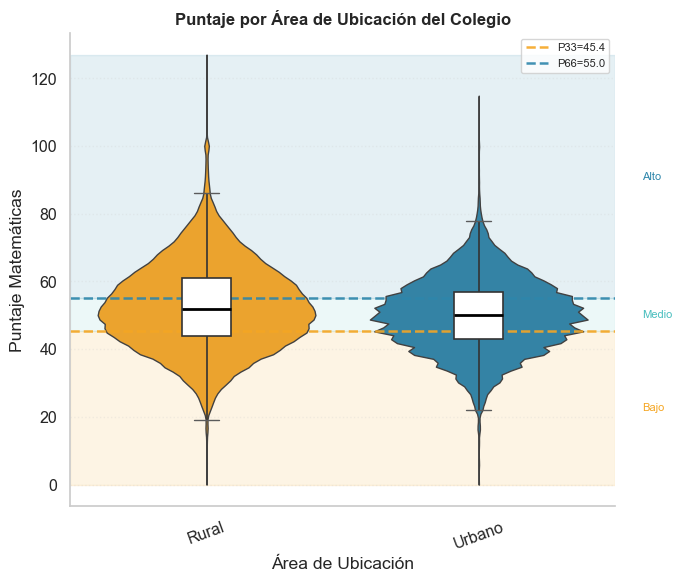

C:\Users\danis\AppData\Local\Temp\ipykernel_16052\3747627729.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


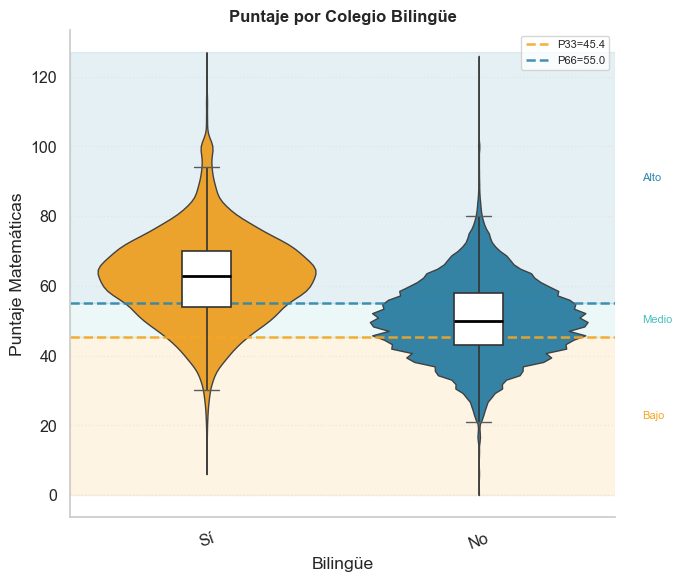

C:\Users\danis\AppData\Local\Temp\ipykernel_16052\3747627729.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


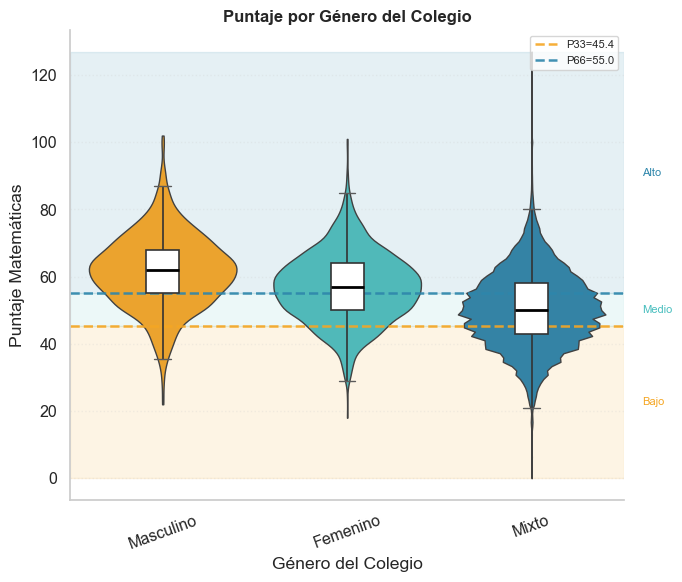

C:\Users\danis\AppData\Local\Temp\ipykernel_16052\3747627729.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


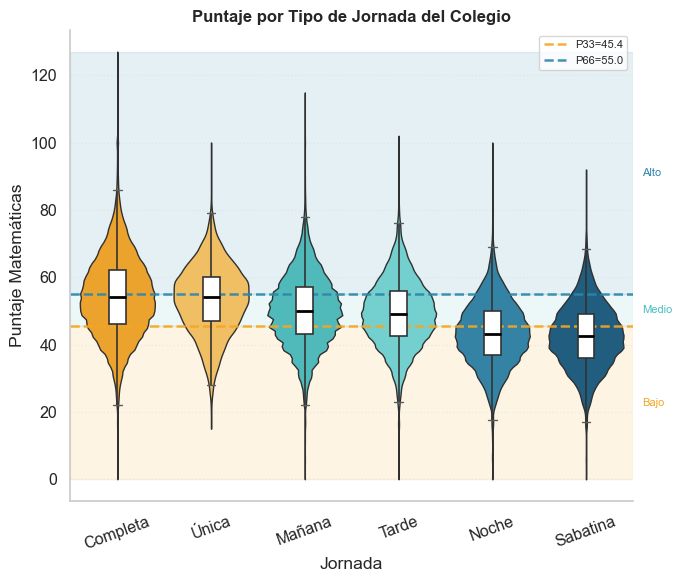

In [13]:
# nombres de las categorias bonitos
df_plot = df.copy()

df_plot['COLE_AREA_UBICACION'] = df_plot['COLE_AREA_UBICACION'].replace({
    'URBANO': 'Urbano',
    'RURAL': 'Rural'
})

df_plot['COLE_BILINGUE'] = df_plot['COLE_BILINGUE'].replace({
    'S': 'Sí',
    'N': 'No'
})

df_plot['COLE_GENERO'] = df_plot['COLE_GENERO'].replace({
    'MASCULINO': 'Masculino',
    'FEMENINO': 'Femenino',
    'MIXTO': 'Mixto'
})

df_plot['COLE_JORNADA'] = df_plot['COLE_JORNADA'].replace({
    'COMPLETA': 'Completa',
    'UNICA': 'Única',
    'MAÑANA': 'Mañana',
    'TARDE': 'Tarde',
    'NOCHE': 'Noche',
    'SABATINA': 'Sabatina'
})

# titulos
TITULOS = {
    'COLE_AREA_UBICACION': 'Puntaje por Área de Ubicación del Colegio',
    'COLE_BILINGUE': 'Puntaje por Colegio Bilingüe',
    'COLE_GENERO': 'Puntaje por Género del Colegio',
    'COLE_JORNADA': 'Puntaje por Tipo de Jornada del Colegio'
}

for i, (var, label) in enumerate(cats):

    # 🔹 NUEVA FIGURA POR VARIABLE
    fig, ax = plt.subplots(figsize=(7, 6), facecolor='white')
    ax.set_facecolor('white')

    orden_cat = df_plot.groupby(var)['PUNT_MATEMATICAS'].median().sort_values(ascending=False).index.tolist()
    palette = PALETAS.get(var, ['#4ABFBF'])

    # violin
    sns.violinplot(
        data=df_plot, x=var, y='PUNT_MATEMATICAS',
        order=orden_cat, palette=palette,
        inner=None, linewidth=1, cut=0, saturation=0.9, ax=ax
    )

    # boxplot
    sns.boxplot(
        data=df_plot, x=var, y='PUNT_MATEMATICAS',
        order=orden_cat, width=0.18, showcaps=True,
        boxprops={'facecolor': 'white', 'edgecolor': '#333333', 'linewidth': 1.2},
        whiskerprops={'color': '#333333', 'linewidth': 1.2},
        medianprops={'color': '#000000', 'linewidth': 2},
        showfliers=False, ax=ax, zorder=3
    )

    # percentiles
    ax.axhline(p33, color=C['Bajo'], ls='--', lw=1.8, alpha=0.9,
               label=f'P33={p33:.1f}')
    ax.axhline(p66, color=C['Alto'], ls='--', lw=1.8, alpha=0.9,
               label=f'P66={p66:.1f}')

    # zonas
    ymin = df_plot['PUNT_MATEMATICAS'].min()
    ymax = df_plot['PUNT_MATEMATICAS'].max()
    ax.axhspan(ymin, p33, alpha=0.12, color=C['Bajo'],  zorder=0)
    ax.axhspan(p33,  p66, alpha=0.10, color=C['Medio'], zorder=0)
    ax.axhspan(p66,  ymax, alpha=0.12, color=C['Alto'], zorder=0)

    ax.text(len(orden_cat)-0.4, (ymin + p33) / 2, 'Bajo',  color=C['Bajo'],  fontsize=8, va='center')
    ax.text(len(orden_cat)-0.4, (p33 + p66) / 2, 'Medio', color=C['Medio'], fontsize=8, va='center')
    ax.text(len(orden_cat)-0.4, (p66 + ymax) / 2, 'Alto',  color=C['Alto'],  fontsize=8, va='center')

    # estilo
    ax.set_title(TITULOS[var], fontweight='bold', fontsize=12)
    ax.set_xlabel(label)
    ax.set_ylabel('Puntaje Matemáticas')
    ax.tick_params(axis='x', rotation=20)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle=':', alpha=0.25)

    ax.legend(fontsize=8, loc='upper right')

    plt.tight_layout()

    plt.show()

## tablas de conteo y porcentajes

In [14]:
#contar cuantas de cada nivel vs cada categoria de colegio 
def resumen_categoria(df, variable):
    tabla = pd.crosstab(df[variable], df['NIVEL_MATEMATICAS'])
    tabla_pct = pd.crosstab(df[variable], df['NIVEL_MATEMATICAS'], normalize='index') * 100
    
    print(f"\n Conteo - {variable}")
    display(tabla)
    
    print(f"\nPorcentaje(%) - {variable}")
    display(tabla_pct.round(2))

In [15]:
resumen_categoria(df, 'COLE_AREA_UBICACION')
resumen_categoria(df, 'COLE_BILINGUE')
resumen_categoria(df, 'COLE_GENERO')
resumen_categoria(df, 'COLE_JORNADA')


 Conteo - COLE_AREA_UBICACION


NIVEL_MATEMATICAS,Alto,Bajo,Medio
COLE_AREA_UBICACION,,,
RURAL,30846,21209,20258
URBANO,109755,107341,103856



Porcentaje(%) - COLE_AREA_UBICACION


NIVEL_MATEMATICAS,Alto,Bajo,Medio
COLE_AREA_UBICACION,,,
RURAL,42.66,29.33,28.01
URBANO,34.20,33.44,32.36



 Conteo - COLE_BILINGUE


...

NIVEL_MATEMATICAS,Alto,Bajo,Medio
COLE_GENERO,,,
FEMENINO,59.81,12.85,27.34
MASCULINO,75.85,6.67,17.48
MIXTO,35.32,33.01,31.66



 Conteo - COLE_JORNADA


NIVEL_MATEMATICAS,Alto,Bajo,Medio
COLE_JORNADA,,,
COMPLETA,48439,22550,28517
MAÑANA,60578,57558,59645
NOCHE,3107,14960,7502
SABATINA,2501,15085,6696
TARDE,9252,10603,10832
UNICA,16724,7794,10922



Porcentaje(%) - COLE_JORNADA


NIVEL_MATEMATICAS,Alto,Bajo,Medio
COLE_JORNADA,,,
COMPLETA,48.68,22.66,28.66
MAÑANA,34.07,32.38,33.55
NOCHE,12.15,58.51,29.34
SABATINA,10.30,62.12,27.58
TARDE,30.15,34.55,35.30
UNICA,47.19,21.99,30.82


## Mapas de Calor

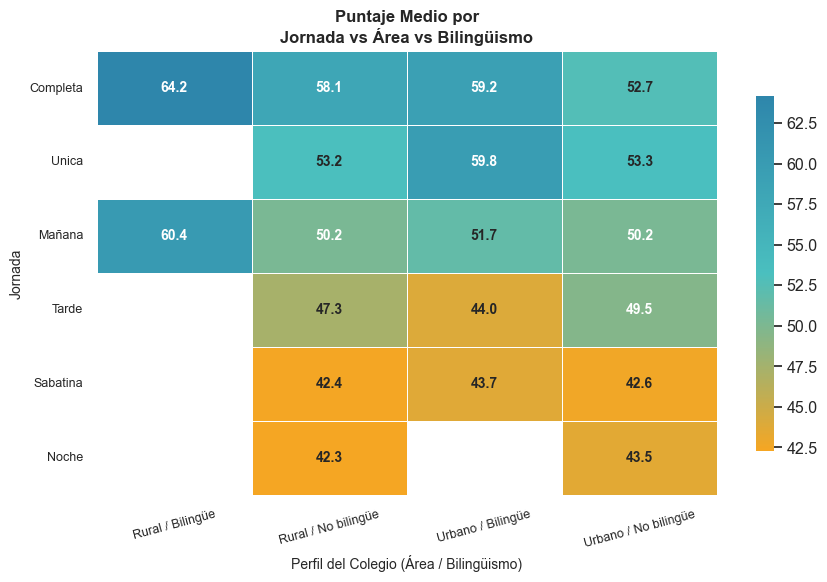

► Correlación más alta con puntaje: Bilingüe (positiva) y Jornada (negativa).
  El perfil Urbano/Bilingüe en jornada Completa o Única tiene el puntaje más alto.


In [16]:
from matplotlib.colors import LinearSegmentedColormap

# Paleta de colores personalizada (Bajo → Medio → Alto)
cmap_custom = LinearSegmentedColormap.from_list(
    'custom_palette',
    ['#F5A623', '#4ABFBF', '#2E86AB']
)

# ── Etiquetas en minúsculas con primera letra mayúscula ──────
etiquetas = ['Área\n(0=Urb, 1=Rur)', 'Bilingüe\n(0=No, 1=Sí)',
             'Género\n(1=Mix,2=F,3=M)', 'Jornada\n(1=Mañ...6=Sab)',
             'Puntaje\nMatemáticas']

cols_num = ['COLE_AREA_UBICACION_NUM', 'COLE_BILINGUE_NUM',
            'COLE_GENERO_NUM', 'COLE_JORNADA_NUM', 'PUNT_MATEMATICAS']

corr = df_limpio[['COLE_AREA_UBICACION_NUM', 'COLE_BILINGUE_NUM',
                   'COLE_GENERO_NUM', 'COLE_JORNADA_NUM']].join(
       df['PUNT_MATEMATICAS']).corr()

corr.index   = etiquetas
corr.columns = etiquetas

######mapa de calor#########

#nombres bonitos
df['PERFIL'] = (
    df['COLE_AREA_UBICACION'].str.capitalize() + ' / ' +
    df['COLE_BILINGUE'].map({'S': 'Bilingüe', 'N': 'No bilingüe'})
)

#jornada en minúsculas con primera letra mayúscula
df['JORNADA_LABEL'] = df['COLE_JORNADA'].str.capitalize()

pivot = df.pivot_table(
    values='PUNT_MATEMATICAS',
    index='JORNADA_LABEL',
    columns='PERFIL',
    aggfunc='mean'
).round(1)

# Ordenar filas por puntaje medio descendente
pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]

fig2, ax2 = plt.subplots(figsize=(9, 6), facecolor='white')
ax2.set_facecolor('white')

sns.heatmap(
    pivot,
    annot=True, fmt='.1f',
    cmap=cmap_custom,         
    linewidths=0.7, linecolor='white',
    annot_kws={'size': 10, 'weight': 'bold'},
    cbar_kws={'shrink': 0.8},
    ax=ax2
)

for spine in ax2.spines.values():
    spine.set_visible(False)

ax2.set_title('Puntaje Medio por\nJornada vs Área vs Bilingüismo',
              fontweight='bold', fontsize=12)
ax2.set_xlabel('Perfil del Colegio (Área / Bilingüismo)', fontsize=10)
ax2.set_ylabel('Jornada', fontsize=10)
ax2.tick_params(axis='x', rotation=15, labelsize=9)
ax2.tick_params(axis='y', rotation=0,  labelsize=9)

sns.set_style("white") 
ax2.grid(False)  
plt.tight_layout()
plt.show()

print('► Correlación más alta con puntaje: Bilingüe (positiva) y Jornada (negativa).')
print('  El perfil Urbano/Bilingüe en jornada Completa o Única tiene el puntaje más alto.')


# Dataframe final para hacer el modelo

In [18]:
# Clasificar PUNT_MATEMATICAS en niveles usando percentiles 33 y 66
p33 = df['PUNT_MATEMATICAS'].quantile(0.33)
p66 = df['PUNT_MATEMATICAS'].quantile(0.66)

def clasificar_nivel(p):
    if pd.isna(p):   return np.nan
    elif p < p33:    return 1  # Bajo
    elif p < p66:    return 2  # Medio
    else:            return 3  # Alto

df['NIVEL_MATEMATICAS'] = df['PUNT_MATEMATICAS'].apply(clasificar_nivel)

# DataFrame para el modelo: features numéricas + target
df_modelo = df[[
    'COLE_AREA_UBICACION_NUM',
    'COLE_BILINGUE_NUM',
    'COLE_GENERO_NUM',
    'COLE_JORNADA_NUM',
    'NIVEL_MATEMATICAS',
]].dropna().reset_index(drop=True)

# df_limpio mantiene solo las features (sin target)
df_limpio = df_modelo.drop(columns=['NIVEL_MATEMATICAS'])

#datos de resumen
print(f'\nUmbrales — Bajo: < {p33:.1f} | Medio: [{p33:.1f}, {p66:.1f}) | Alto: >= {p66:.1f}')
print(f'Shape df_modelo : {df_modelo.shape}')
print(f'Nulos restantes : {df_modelo.isna().sum().sum()}')
print('\nDistribución NIVEL_MATEMATICAS:')
print(
    df_modelo['NIVEL_MATEMATICAS']
    .value_counts()
    .sort_index()
    .rename({1: 'Bajo', 2: 'Medio', 3: 'Alto'})
)

#guardar CSV del modelo
output_path = 'df_modelo.csv'
df_modelo.to_csv(output_path, index=False)
print(df_modelo.head())



Umbrales — Bajo: < 45.4 | Medio: [45.4, 55.0) | Alto: >= 55.0
Shape df_modelo : (393265, 5)
Nulos restantes : 0

Distribución NIVEL_MATEMATICAS:
NIVEL_MATEMATICAS
Bajo     128550
Medio    124114
Alto     140601
Name: count, dtype: int64
   COLE_AREA_UBICACION_NUM  COLE_BILINGUE_NUM  COLE_GENERO_NUM  \
0                        0                  0                1   
1                        0                  0                1   
2                        0                  0                1   
3                        1                  0                1   
4                        0                  0                1   

   COLE_JORNADA_NUM  NIVEL_MATEMATICAS  
0                 3                  1  
1                 6                  3  
2                 2                  2  
3                 6                  1  
4                 3                  3  
